In [1]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize # my name is shrouq [my,name,is ,shrouq]
from sklearn.feature_extraction.text import TfidfVectorizer # MY name is shrouq
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("/content/Disease precaution.csv")

In [3]:
# Create a copy to work on
df_copy = df.copy()

In [4]:
# see the info about data
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Disease       41 non-null     object
 1   Precaution_1  41 non-null     object
 2   Precaution_2  41 non-null     object
 3   Precaution_3  40 non-null     object
 4   Precaution_4  40 non-null     object
dtypes: object(5)
memory usage: 1.7+ KB


In [5]:
# Drop unnecessary index column if exists
if 'Unnamed: 0' in df_copy.columns:
    df_copy.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
# Handle missing values
# Assuming 'Precaution' columns are textual and should be filled with a placeholder like 'Not Available'
df_copy['Precaution_1'].fillna('Not Available', inplace=True)
df_copy['Precaution_2'].fillna('Not Available', inplace=True)
df_copy['Precaution_3'].fillna('Not Available', inplace=True)


<ipython-input-6-d9ff4ce3db4d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Precaution_1'].fillna('Not Available', inplace=True)
<ipython-input-6-d9ff4ce3db4d>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [7]:
# Ensure text column is properly cleaned
df_copy['Disease'] = df_copy['Disease'].astype(str).str.lower()
df_copy['Precaution_1'] = df_copy['Precaution_1'].astype(str).str.lower()
df_copy['Precaution_2'] = df_copy['Precaution_2'].astype(str).str.lower()
df_copy['Precaution_3'] = df_copy['Precaution_3'].astype(str).str.lower()
df_copy['Precaution_4'] = df_copy['Precaution_4'].astype(str).str.lower()

In [8]:
print(df.head()) #show frist 5 rows

          Disease                      Precaution_1  \
0   Drug Reaction                   stop irritation   
1         Malaria          Consult nearest hospital   
2         Allergy                    apply calamine   
3  Hypothyroidism                     reduce stress   
4       Psoriasis  wash hands with warm soapy water   

                   Precaution_2        Precaution_3  \
0      consult nearest hospital    stop taking drug   
1               avoid oily food  avoid non veg food   
2       cover area with bandage                 NaN   
3                      exercise         eat healthy   
4  stop bleeding using pressure      consult doctor   

                  Precaution_4  
0                    follow up  
1           keep mosquitos out  
2  use ice to compress itching  
3             get proper sleep  
4                   salt baths  


In [9]:
print(df.tail(10)) #show last 10 rows

                Disease                      Precaution_1  \
31  Alcoholic hepatitis          stop alcohol consumption   
32             Jaundice             drink plenty of water   
33          Hepatitis E          stop alcohol consumption   
34               Dengue           drink papaya leaf juice   
35          Hepatitis D                    consult doctor   
36         Heart attack                    call ambulance   
37            Pneumonia                    consult doctor   
38            Arthritis                          exercise   
39      Gastroenteritis  stop eating solid food for while   
40         Tuberculosis                       cover mouth   

                      Precaution_2                       Precaution_3  \
31                  consult doctor                         medication   
32            consume milk thistle  eat fruits and high fiberous food   
33                            rest                     consult doctor   
34          avoid fatty spicy food  

In [10]:
# display statistics measures
print("original dataset describtion :")
print(df.describe())

original dataset describtion :
              Disease              Precaution_1 Precaution_2    Precaution_3  \
count              41                        41           41              40   
unique             41                        32           34              30   
top     Drug Reaction  Consult nearest hospital     exercise  consult doctor   
freq                1                         3            3               6   

       Precaution_4  
count            40  
unique           24  
top       follow up  
freq              6  


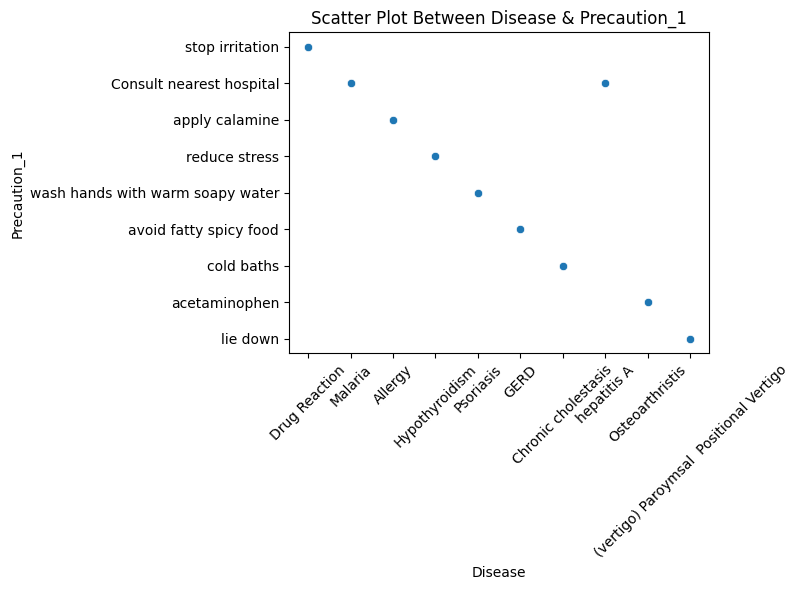

In [11]:
# visualize using scatter plot between Disease & Precaution_1
import matplotlib.pyplot as plt  # Ensure matplotlib.pyplot is imported

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.head(10), x='Disease', y='Precaution_1')

plt.title("Scatter Plot Between Disease & Precaution_1")
plt.xlabel=("Disease")  # Calling the function plt.xlabel
plt.ylabel=("Precaution_1")      # Calling the function plt.ylabel
plt.xticks(rotation=45)  # Optional: rotates x-axis labels for readability
plt.tight_layout()       # Adjusts layout to fit labels
plt.show()

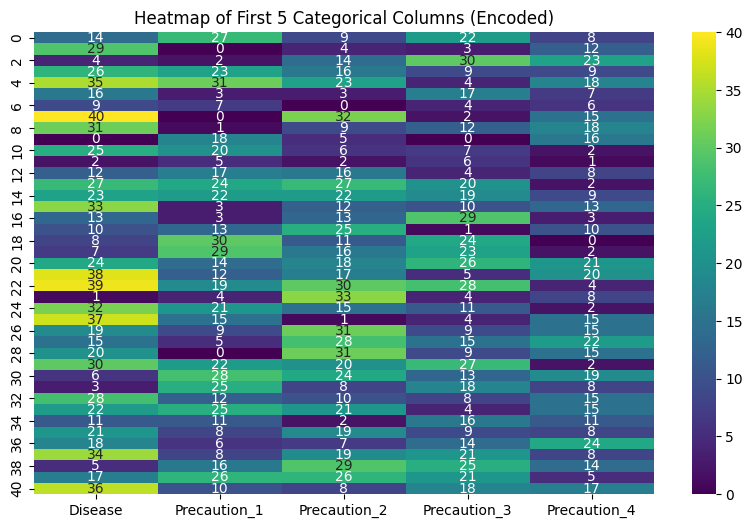

In [12]:
from sklearn.preprocessing import LabelEncoder

# Label encode the first 5 columns
df_encoded = df.iloc[:, :5].apply(LabelEncoder().fit_transform)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded, cmap="viridis", annot=True, cbar=True)
plt.title("Heatmap of First 5 Categorical Columns (Encoded)")
plt.xlabel=("Columns")
plt.ylabel=("Rows")
plt.show()

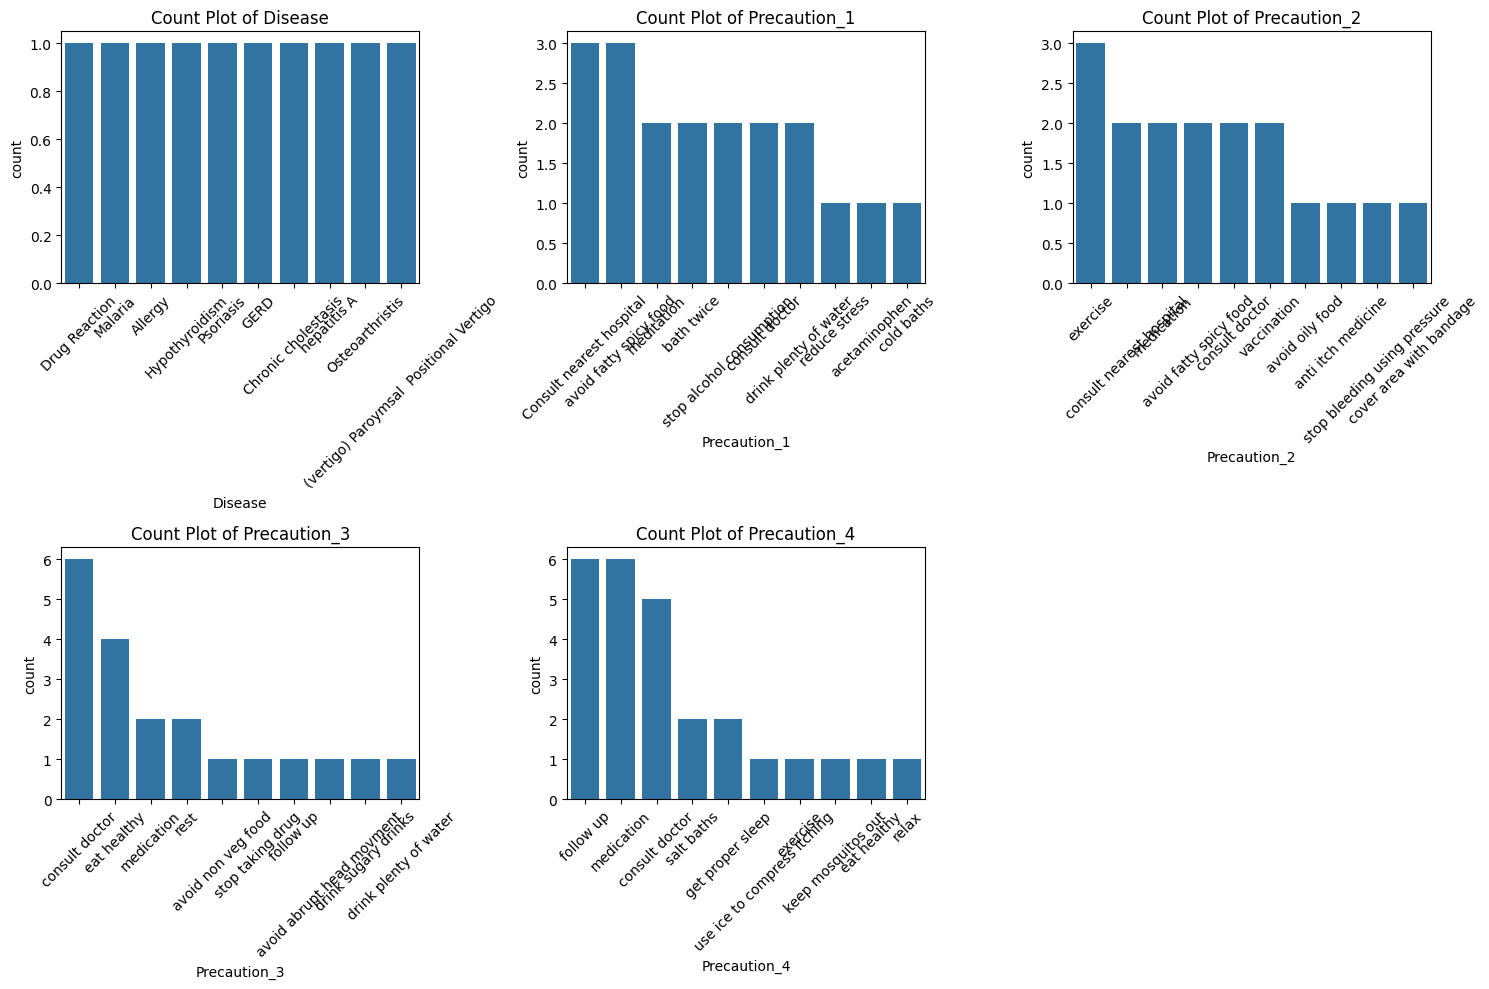

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# First 5 columns
cols = df.columns[:5]

# Set up plot
plt.figure(figsize=(15, 10))

# Loop through each column and plot
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns layout
    sns.countplot(data=df, x=col, order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

In [14]:
# Chatbot functions
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2)) #my name is shrouq [my name , name is ,is shrouq]
item_vectors = vectorizer.fit_transform(df_copy[['Disease','Precaution_1','Precaution_2','Precaution_3','Precaution_4']].apply(lambda x: ' '.join(x.astype(str)), axis=1))

def recommend_items(user_query, top_n=5):
    query_vector = vectorizer.transform([user_query.lower()])
    similarities = cosine_similarity(query_vector, item_vectors).flatten()

    # Get indices of relevant items above a similarity threshold
    relevant_indices = [i for i in similarities.argsort()[::-1] if similarities[i] > 0.1][:top_n]

    if not relevant_indices:
        return "Sorry, no Disease & Precaution found. Try describing differently."

    # Select relevant columns for disease and precautions
    recommended_items = df_copy.iloc[relevant_indices][['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]

    # Drop duplicates and reset index
    recommended_items = recommended_items.drop_duplicates().reset_index(drop=True)

    # Create the result string
    result = "\nHere are some recommended diseases and their precautions:\n"
    for _, row in recommended_items.iterrows():
        result += f"Disease: {row['Disease']}\n"
        result += f"Precautions:\n"
        result += f"  1. {row['Precaution_1']}\n"
        result += f"  2. {row['Precaution_2']}\n"
        result += f"  3. {row['Precaution_3']}\n"
        result += f"  4. {row['Precaution_4']}\n\n"

    return result


def handle_disease_support(user_query):
    # Disease precaution database
    disease_precautions = {
        "flu": [
            "Drink plenty of fluids",
            "Get adequate rest",
            "Take antiviral medication if prescribed",
            "Avoid close contact with others"
        ],
        "diabetes": [
            "Maintain a healthy diet",
            "Monitor blood sugar levels regularly",
            "Exercise regularly",
            "Take insulin or medication as prescribed"
        ],
        "malaria": [
            "Use mosquito nets",
            "Wear full-sleeve clothes",
            "Apply insect repellent",
            "Avoid stagnant water"
        ],
        "covid": [
            "Wear a mask in public",
            "Wash hands regularly",
            "Maintain social distancing",
            "Avoid crowded places"
        ]
    }

    # Benefits of knowing disease precautions
    benefits_precautions = [
        "Prevention is better than cure",
        "Protects others too",
        "Faster recovery",
        "Reduces complications",
        "Cost-effective",
        "Peace of mind"
    ]

    query = user_query.lower()

    # Check if the disease is mentioned in the user query
    for disease, precautions in disease_precautions.items():
        if disease in query:
            response = f"Precautions for {disease.title()}:\n"
            for i, p in enumerate(precautions, start=1):
                response += f"{i}. {p}\n"
            return response

    # Check if the user is asking about general benefits of precautions
    if "precautions" in query and any(word in query for word in ["benefit", "importance", "why"]):
        response = "Benefits of Knowing Disease Precautions:\n"
        for i, benefit in enumerate(benefits_precautions, start=1):
            response += f"{i}. {benefit}\n"
        return response

    return "Sorry, I couldn't identify the disease or your request. Please try mentioning a disease name or ask about the benefits of precautions."


def chatbot():
    print("Welcome to the Chatbot! Type 'exit' to stop.")
    while True:
        user_query = input("You: ")
        if user_query.lower() == 'exit':
            print("Chatbot: Thank you for visiting! Have a great day!")
            break
        # If query matches support keywords, return a support response
        if any(keyword in user_query.lower() for keyword in ["flu", "diabetes", "malaria", "covid" , "benefits_precautions"]):
            print("Chatbot:", handle_disease_support(user_query)) #Fixed: Calling handle_disease_support instead of handle_customer_support
        else:
            print("Chatbot:", recommend_items(user_query))  # Default to recommendation system

# Start chatbot
chatbot()

Welcome to the Chatbot! Type 'exit' to stop.
You: flu
Chatbot: Precautions for Flu:
1. Drink plenty of fluids
2. Get adequate rest
3. Take antiviral medication if prescribed
4. Avoid close contact with others

You: malaria
Chatbot: Precautions for Malaria:
1. Use mosquito nets
2. Wear full-sleeve clothes
3. Apply insect repellent
4. Avoid stagnant water

You: covid-19
Chatbot: Precautions for Covid:
1. Wear a mask in public
2. Wash hands regularly
3. Maintain social distancing
4. Avoid crowded places

You: Benefits of knowing disease precautions
Chatbot: Sorry, no Disease & Precaution found. Try describing differently.
You: benefits_precautions
Chatbot: Benefits of Knowing Disease Precautions:
1. Prevention is better than cure
2. Protects others too
3. Faster recovery
4. Reduces complications
5. Cost-effective
6. Peace of mind

You: Allergy
Chatbot: 
Here are some recommended diseases and their precautions:
Disease: allergy
Precautions:
  1. apply calamine
  2. cover area with bandage
